# A tutorial on PyMC

**Day 2, 12:00 — 60 minutes.** Alexander Fengler.

![](../../images/logos/pymc-logo.png){width=320 fig-alt="PyMC logo"}

PyMC lets you write a generative model in Python in a "forward" way and then perform inference via a simple function call.
This session builds that from the bottom: what a distribution object *is*,
what a model is made of, what `pm.sample()` actually hands you, and how to
look at it. We finish by writing a regression twice — once by hand, once in
one line with **bambi** — so you can see exactly what the shortcut is doing.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import bambi as bmb
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-pymc"))
rng = np.random.default_rng(RANDOM_SEED)

print("pymc", pm.__version__, "| arviz", az.__version__, "| bambi", bmb.__version__)

pymc 6.2.0 | arviz 1.2.0 | bambi 0.19.0


## Where PyMC comes from, and what it actually does

**PyMC is a probabilistic programming library.** You write down a generative
model — priors, then how data arise from them — and the library works out how
to condition that model on observed data. You never write a sampler.

### A very short history

PyMC has been developed since the mid-2000s, making it one of the older
projects in this space. The version most people met, **PyMC3**, was built on
**Theano** — an early symbolic-computation and automatic-differentiation
library from the deep-learning world. When Theano's upstream development wound
down, the PyMC team took over maintenance and eventually forked it into what
is now **PyTensor**, the engine under PyMC 5 and 6. That is an unusual
situation worth knowing about: a statistics library ended up maintaining its
own tensor and autodiff engine.

### The idea it shares with deep learning frameworks

When you write

```python
with pm.Model():
    mu = pm.Normal("mu", 0, 1)
    pm.Normal("y", mu=mu, sigma=1, observed=data)
```

nothing is computed yet. You are **building a graph** — a symbolic description
of how quantities depend on one another. PyTensor can then

1. **differentiate** that graph automatically, and
2. **compile** it to fast code (C, numba, or JAX).

If you have used PyTorch or JAX, this is the same core machinery: define a
computation graph, get gradients for free, compile it. What differs is what
the gradients are *for*. In deep learning you differentiate a **loss** and
descend it to a point estimate. Here you differentiate the **log-posterior** 
with respect to model parameters instead. You hand those gradients to a sampler, 
which uses them to *explore* the posterior rather than to minimise anything.
Same engine, different destination: the output is a distribution over parameters,
not a fitted value.

### The neighbourhood

| | what it is |
|---|---|
| **PyMC** | the modelling library — this session |
| **PyTensor** | the graph / autodiff / compile engine underneath |
| **ArviZ** | diagnostics and plotting for whatever you fitted |
| **bambi** | common regressions as formulas; builds the PyMC model for you |
| **nutpie** | a fast NUTS implementation you can swap in |
| **HSSM** | sequential-sampling models on top of PyMC — Day 3, 09:30 |

Comparable tools elsewhere: **Stan** (its own language, very mature),
**NumPyro** and **Pyro** (on JAX and PyTorch), **Turing.jl** (Julia). The
concepts transfer directly; the syntax does not.

::: {.callout-tip}
## The one sentence to keep
You describe the *generative story*; the library turns it into a
differentiable graph and samples the posterior for you.
:::

::: {.callout-warning}
## Read this before you copy code off the internet
**ArviZ 1.0 (May 2026) was a breaking release.** `az.plot_posterior`,
`az.plot_ppc`, `az.plot_density`, `az.plot_kde` and `az.waic` **no longer
exist**. `az.plot_trace` still exists but now draws *traces only*. The default
credible interval changed from a 94% HDI to an **89% ETI**, so even printed
numbers differ from older material.

Most PyMC tutorials online — including large parts of PyMC's own example
gallery — predate this. If a snippet errors with `AttributeError` on an
`az.plot_*` function, that is why. The pinned `tutorials/uv.lock` guarantees
you are on the versions this notebook was written against.
:::

In [2]:
print("az.plot_posterior exists?", hasattr(az, "plot_posterior"))
print("az.waic exists?          ", hasattr(az, "waic"))
print("use instead: az.plot_dist, az.plot_ppc_dist, az.plot_trace_dist, az.loo")

az.plot_posterior exists? False
az.waic exists?           False
use instead: az.plot_dist, az.plot_ppc_dist, az.plot_trace_dist, az.loo


## 1. What is a PyMC distribution?
### Standalone

This is the piece most tutorials skip, and it is the source of most early
confusion. A PyMC distribution is used in **two different ways**, and they
behave differently.

In [3]:
# (a) Standalone — a distribution object, not attached to anything.
standalone = pm.Normal.dist(mu=0.0, sigma=1.0)
print("type:", type(standalone).__name__)
print("5 draws:", pm.draw(standalone, draws=5, random_seed=RANDOM_SEED).round(3))

# You can also evaluate the log-likelihood (logp) at specific values:
values = np.array([0.0, 1.0, -1.0])
logps = pm.logp(standalone, values).eval()
print("logp at [0.0, 1.0, -1.0]:", np.round(logps, 3))

type: TensorVariable
5 draws: [-0.241 -0.112 -0.713  0.371  0.275]
logp at [0.0, 1.0, -1.0]: [-0.919 -1.419 -1.419]


`pm.Normal.dist(...)` gives you a standalone *distribution* object. It doesn't belong to any model. Use it whenever you want a distribution 

1. as a value
2. inside another distribution
3. as a prior you are inspecting
4. just to simulate from a named distribution

### Densities, not just draws

A distribution also knows its own log-density. This is the quantity every
sampler in this course is actually working with.

logp at 0: -0.9189  (= -0.5*log(2*pi) = -0.9189 )


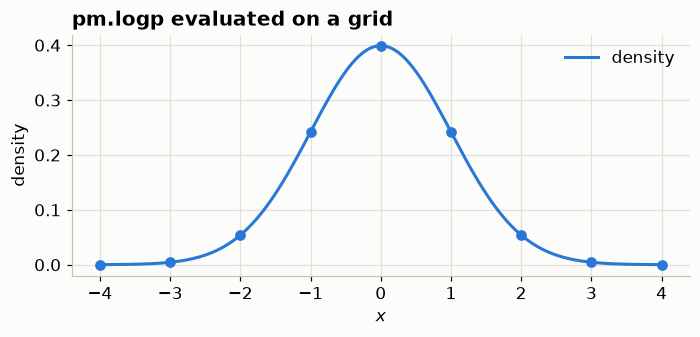

In [4]:
grid = np.linspace(-4, 4, 9)
logp = pm.logp(pm.Normal.dist(0.0, 1.0), grid).eval()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
xs = np.linspace(-4, 4, 300)
ax.plot(xs, np.exp(pm.logp(pm.Normal.dist(0.0, 1.0), xs).eval()),
        color=S.PRIMARY, label="density")
ax.plot(grid, np.exp(logp), "o", color=S.PRIMARY, ms=6, ls="none")
ax.set(title="pm.logp evaluated on a grid", xlabel="$x$", ylabel="density")
ax.legend()
fig.tight_layout()

print("logp at 0:", float(pm.logp(pm.Normal.dist(0.0, 1.0), 0.0).eval()).__round__(4),
      " (= -0.5*log(2*pi) =", round(float(-0.5 * np.log(2 * np.pi)), 4), ")")

Now the second way:

### Distributions inside a PyMC model

In [5]:
# (b) Named, inside a model context — a random VARIABLE in a graph.
with pm.Model() as demo:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)

print("type:", type(mu).__name__)
print("model variables:", [v.name for v in demo.basic_RVs])

type: TensorVariable
model variables: ['mu']


Inside a `with pm.Model()` block, the same call **registers a node in a
graph**. The name is not decoration — it is the key you will use to get the
posterior back out. Two variables cannot share a name.

Try it outside a model context and PyMC tells you exactly what is wrong:

In [6]:
try:
    oops = pm.Normal("mu", 0.0, 1.0)
except TypeError as e:
    print("TypeError:", e)

TypeError: No model on context stack, which is needed to instantiate distributions. Add variable inside a 'with model:' block, or use the '.dist' syntax for a standalone distribution.


> **Poll:**  
What is the difference between `pm.Normal("x", 0, 1)` and `pm.Normal.dist(0, 1)`?  
- **A.** Nothing; `.dist()` is just shorthand.  
- **B.** `.dist()` is faster because it skips validation.  
- **C.** The named form registers a variable in the enclosing model; `.dist()` returns a free-standing distribution belonging to no model.  
- **D.** `.dist()` can only be used for priors.

<details>
<summary>Answer</summary>

**C.** The named form needs a model context and will raise without one. The
`.dist()` form is a value you can draw from, take the logp of, or nest inside
another distribution — which is exactly how you build custom likelihoods and
mixtures.

</details>

## 2. A first model, and what `pm.sample()` returns

The smallest interesting problem: we observe noisy measurements of an unknown
mean and want the posterior over that mean. Written out,

$$
\mu \sim \mathcal{N}(0,\ 10), \qquad
\sigma \sim \text{HalfNormal}(5), \qquad
y_i \mid \mu, \sigma \;\sim\; \mathcal{N}(\mu,\ \sigma)
\quad \text{for } i = 1,\dots,60 .
$$

The first two lines are the **prior**, the third is the **likelihood**. The
code below is a line-for-line transcription of exactly that.

In [7]:
TRUE_MU, TRUE_SIGMA, N = 2.5, 1.5, 60
y_obs = rng.normal(TRUE_MU, TRUE_SIGMA, N)

with pm.Model() as first_model:
    mu = pm.Normal("mu", mu=0.0, sigma=10.0)      # prior
    sigma = pm.HalfNormal("sigma", sigma=5.0)     # prior
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)   # likelihood

    idata = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                      nuts_sampler="pymc", progressbar=False,
                      random_seed=RANDOM_SEED)

print(type(idata))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


<class 'xarray.core.datatree.DataTree'>


### Look at the model before you look at the answer

`pm.model_to_graphviz` draws the graph PyMC built. Shaded nodes are observed,
open nodes are things being estimated, and the box is the *plate* — the 60
observations that share the same `mu` and `sigma`. Reading this before
sampling catches an entire class of mistake: a prior you forgot to connect, a
variable with the wrong shape, an observation that is not actually observed.

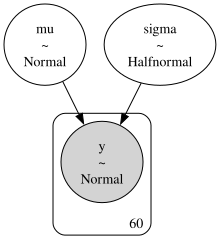

In [8]:
try:
    graph = pm.model_to_graphviz(first_model)
except Exception as exc:                      # graphviz needs the `dot` BINARY
    print(f"graphviz unavailable ({type(exc).__name__}); "
          "showing the mermaid description instead")
    print(pm.model_to_mermaid(first_model))
    graph = None
graph

::: {.callout-note}
## If that cell printed text instead of a picture
`model_to_graphviz` needs the **`dot` system binary**, not just the Python
`graphviz` package — `brew install graphviz` / `apt install graphviz` /
`conda install graphviz`. PyMC 6 also ships `pm.model_to_mermaid()`, which is
pure text and always available, which is what the fallback prints.
:::

::: {.callout-important}
## `pm.sample()` returns an `xarray.DataTree`
In PyMC 6 this is **not** an `arviz.InferenceData` any more. `InferenceData`
still exists as a compatibility shim that warns and hands you a `DataTree`.
The API docstring on the website still says "InferenceData" — the code
disagrees, and the code wins.
:::

A `DataTree` is a tree of labelled groups. Look at what is in it:

In [9]:
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           mu       (chain, draw) float64 32kB 2.452 2.588 2.308 ... 2.604 2.055 2.186
│           sigma    (chain, draw) float64 32kB 1.287 1.298 1.144 ... 1.457 1.212 1.3
│       Attributes:
│           created_at:                 2026-07-26T20:36:15.007505+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              0.4454379081726074
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           step_size              (chain, draw) float64 32kB 1.135 1.135 ... 1.061
│           n_steps                (chain, draw) float64 32kB 1.0 3.0 3.0 ... 3.0 1.0
│           diverging              (chain, draw) bool 4kB False False ... False False
│           max_energy_error       (chain, draw) float64 32kB -0.02741 ... -0.9951
│           energy_error           (chain, draw) float64 32kB -0.02741 ... -0.9951
│           divergences            (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           ...                     ...
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│           perf_counter_diff      (chain, draw) float64 32kB 2.033e-05 ... 2.125e-05
│           tree_depth             (chain, draw) int64 32kB 1 2 2 2 2 2 ... 2 2 2 1 2 1
│           lp                     (chain, draw) float64 32kB -103.1 -103.2 ... -104.8
│           step_size_bar          (chain, draw) float64 32kB 1.196 1.196 ... 1.124
│           acceptance_rate        (chain, draw) float64 32kB 1.0 0.763 ... 0.6543 1.0
│       Attributes:
│           created_at:                 2026-07-26T20:36:15.011285+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              0.4454379081726074
│           tuning_steps:               1000
└── Group: /observed_data
        Dimensions:  (y_dim_0: 60)
        Coordinates:
          * y_dim_0  (y_dim_0) int64 480B 0 1 2 3 4 5 6 7 8 ... 52 53 54 55 56 57 58 59
        Data variables:
            y        (y_dim_0) float64 480B 2.587 2.781 4.849 ... 2.398 5.916 0.2535
        Attributes:
            created_at:                 2026-07-26T20:36:15.012385+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.2.0
            sample_dims:                []

In [10]:
list(idata.children)

['posterior', 'sample_stats', 'observed_data']

In [11]:

idata["posterior"].dataset

<xarray.DatasetView> Size: 72kB
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    mu       (chain, draw) float64 32kB 2.452 2.588 2.308 ... 2.604 2.055 2.186
    sigma    (chain, draw) float64 32kB 1.287 1.298 1.144 ... 1.457 1.212 1.3
Attributes:
    created_at:                 2026-07-26T20:36:15.007505+00:00
    creation_library:           ArviZ
    creation_library_version:   1.2.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['chain', 'draw']
    sampling_time:              0.4454379081726074
    tuning_steps:               1000

### The gotcha that costs everyone twenty minutes

`idata.posterior` is a **DataTree node**, not a `Dataset`. Most `xarray`
operations you want live on the `Dataset`, so reach through `.dataset`:

In [12]:
print("idata.posterior       ->", type(idata.posterior).__name__)
print("idata.posterior.dataset ->", type(idata.posterior.dataset).__name__)
print("idata.posterior['mu'] ->", type(idata.posterior["mu"]).__name__)
print()

post = idata.posterior.dataset
print("shape (chain, draw):", post["mu"].shape)
print("posterior mean mu = %.3f   (true %.1f)" % (post["mu"].values.mean(), TRUE_MU))
print("posterior mean sigma = %.3f (true %.1f)" % (post["sigma"].values.mean(), TRUE_SIGMA))

idata.posterior       -> DataTree
idata.posterior.dataset -> DatasetView
idata.posterior['mu'] -> DataArray

shape (chain, draw): (4, 1000)
posterior mean mu = 2.497   (true 2.5)
posterior mean sigma = 1.278 (true 1.5)


The `sample_stats` group is where the sampler records what it did. This is
where divergences live — we will make use of it during out Day 3 tutorials.

In [13]:
print(sorted(idata["sample_stats"].dataset.data_vars))

['acceptance_rate', 'divergences', 'diverging', 'energy', 'energy_error', 'index_in_trajectory', 'largest_eigval', 'lp', 'max_energy_error', 'n_steps', 'perf_counter_diff', 'perf_counter_start', 'process_time_diff', 'reached_max_treedepth', 'smallest_eigval', 'step_size', 'step_size_bar', 'tree_depth']


## 3. Looking at a posterior with ArviZ 1.x

In [14]:
print(az.summary(idata, kind="stats").to_string())

      mean    sd eti89_lb eti89_ub
mu     2.5  0.17      2.2      2.8
sigma  1.3  0.12      1.1      1.5


Note the interval columns: **89% ETI**, not the 94% HDI you may remember.
You can ask for something else explicitly:

In [15]:
print(az.summary(idata, kind="stats", ci_prob=0.94, ci_kind="hdi").to_string())

      mean    sd hdi94_lb hdi94_ub
mu     2.5  0.17      2.2      2.8
sigma  1.3  0.12      1.1      1.5


The standard first look is `plot_trace_dist` — marginals on the left, traces
on the right.

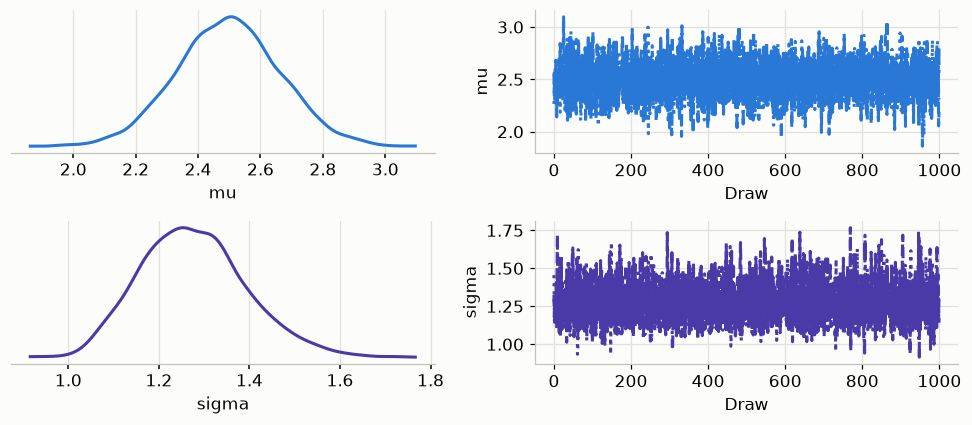

In [16]:
az.plot_trace_dist(idata, combined=True)
plt.gcf().set_size_inches(9, 4)
plt.tight_layout()

And the joint, which we will care about a great deal this afternoon.
`az.plot_pair` gives the marginals on the diagonal and the joint off it.
`marginal_kind="kde"` smooths the marginals into densities rather than
histograms.

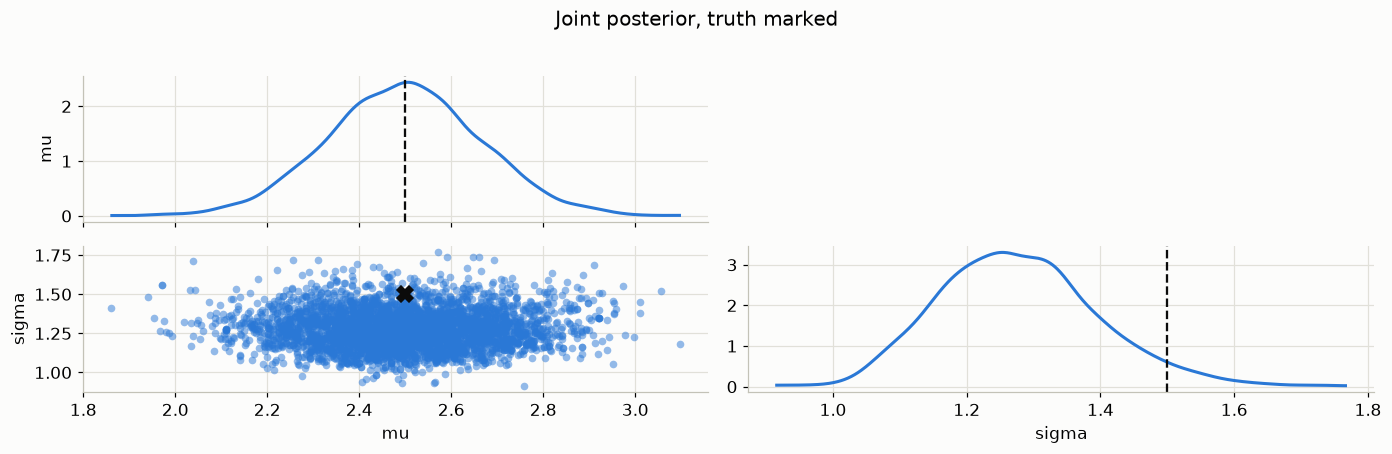

In [17]:
pair = az.plot_pair(idata, var_names=["mu", "sigma"],
                    marginal=True, marginal_kind="kde")

# ArviZ returns a PlotMatrix, not a bare matplotlib figure. `get_target` hands
# back the Axes for a given panel, which is how we add anything ArviZ does not
# draw itself — here, the true values used to generate the data.
S.truth_point(pair.get_target("mu", {}, "sigma", {}), TRUE_MU, TRUE_SIGMA)
for var, truth in [("mu", TRUE_MU), ("sigma", TRUE_SIGMA)]:
    pair.get_target(var, {}).axvline(truth, color=S.TRUTH, ls="--", lw=1.5)

plt.gcf().suptitle("Joint posterior, truth marked", y=1.02)
plt.tight_layout()

::: {.callout-note}
## Marking ground truth is a habit worth forming
ArviZ has no "true value" argument, because in real analyses there is no true
value to pass — you only have this when you generated the data yourself. That
is exactly why it is worth doing whenever you *can*: a plot with the truth on
it answers "did this work?" in one glance, and simulating data with known
parameters is the cheapest way to check a model before trusting it on real
data. We use the same trick throughout Day 2 and Day 3.
:::

`mu` and `sigma` are close to independent here — a round blob, and the truth
sits inside it. Remember what this looks like; by 15:00 today you will be
looking at one that is not.

### What conditioning on data actually did

Two pictures make the whole point of Bayesian inference concrete. Both compare
*before seeing the data* with *after*.

**Prior to posterior** is contraction in **parameter** space: the prior says
what we were willing to believe, the posterior says what survives contact with
60 observations.

Sampling: [mu, sigma, y]


sd(mu): prior  10.032 -> posterior  0.166   (60x narrower)
sd(sigma): prior   2.942 -> posterior  0.120   (25x narrower)


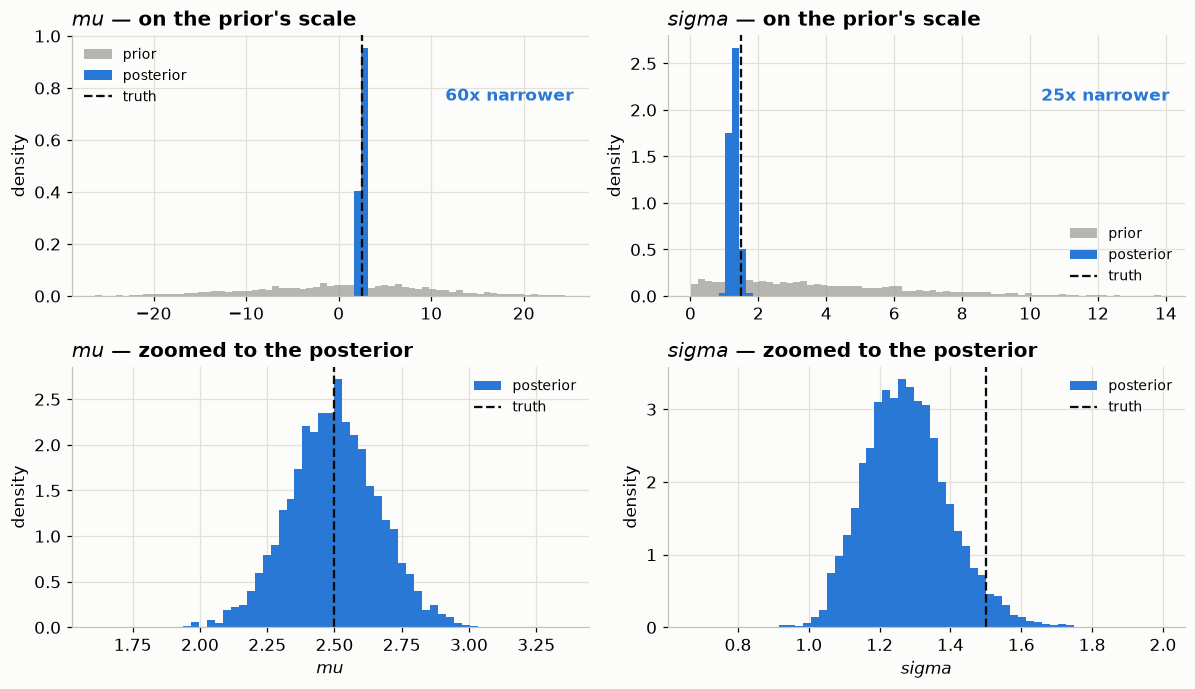

In [18]:
with first_model:
    prior = pm.sample_prior_predictive(draws=2000, random_seed=RANDOM_SEED)

# Two rows: the top shows the contraction, the bottom zooms in so the posterior
# is more than a spike. Both are needed — the first is the message, the second
# is the shape.
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
for col, (var, truth) in enumerate([("mu", TRUE_MU), ("sigma", TRUE_SIGMA)]):
    pri = prior["prior"].dataset[var].values.ravel()
    pos = post[var].values.ravel()

    # top: full prior range
    ax = axes[0, col]
    lo, hi = np.percentile(pri, [0.5, 99.5])
    bins = np.linspace(lo, hi, 70)
    ax.hist(pri, bins=bins, density=True, color=S.MUTED, alpha=0.6, label="prior")
    ax.hist(pos, bins=bins, density=True, color=S.PRIMARY, label="posterior")
    S.truth_line(ax, truth, axis="x")
    ax.set(title=f"${var}$ — on the prior's scale", ylabel="density")
    ax.legend(fontsize=9)

    # bottom: zoomed to the posterior
    ax = axes[1, col]
    zlo, zhi = np.percentile(pos, [0.1, 99.9])
    pad = 0.35 * (zhi - zlo)
    zbins = np.linspace(zlo - pad, zhi + pad, 60)
    ax.hist(pos, bins=zbins, density=True, color=S.PRIMARY, label="posterior")
    S.truth_line(ax, truth, axis="x")
    ax.set(title=f"${var}$ — zoomed to the posterior", xlabel=f"${var}$",
           ylabel="density")
    ax.legend(fontsize=9)

    shrink = pri.std() / pos.std()
    axes[0, col].annotate(f"{shrink:.0f}x narrower", xy=(0.97, 0.75),
                          xycoords="axes fraction", ha="right",
                          color=S.PRIMARY, fontweight="bold")
fig.tight_layout()

for var in ["mu", "sigma"]:
    pri = prior["prior"].dataset[var].values.ravel()
    pos = post[var].values.ravel()
    print(f"sd({var}): prior {pri.std():7.3f} -> posterior {pos.std():6.3f}"
          f"   ({pri.std()/pos.std():.0f}x narrower)")

The posterior is dramatically narrower than the prior. That narrowing *is* the
information the data carried — and it is why "what is your prior?" and "how
wide is it?" are really the same question.

Look at the bottom-right panel before moving on: the true $\sigma = 1.5$ sits
in the **right tail** of its posterior, not in the middle. With 60
observations that is ordinary sampling variability, not a bug — a 89%
interval misses the truth roughly 11% of the time, by construction. Being
calibrated does not mean being right every time, and a posterior that always
covered the truth dead-centre would be a suspiciously overconfident one.

**Prior predictive to posterior predictive** is the same story in **data**
space: what datasets did the model consider plausible before and after?

Sampling: [y]


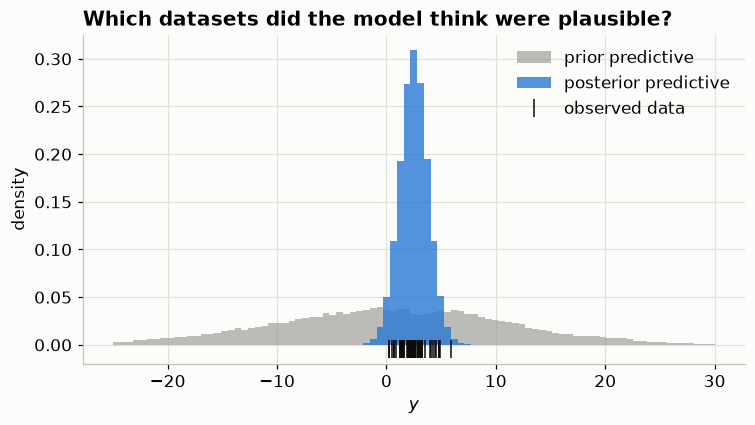

In [19]:
with first_model:
    ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED,
                                         progressbar=False)

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-25, 30, 90)
ax.hist(prior["prior_predictive"].dataset["y"].values.ravel(), bins=bins,
        density=True, color=S.MUTED, alpha=0.55, label="prior predictive")
ax.hist(ppc["posterior_predictive"].dataset["y"].values.ravel(), bins=bins,
        density=True, color=S.PRIMARY, alpha=0.8, label="posterior predictive")
ax.plot(y_obs, np.full_like(y_obs, -0.004), "|", color=S.TRUTH, ms=12,
        label="observed data")
ax.set(title="Which datasets did the model think were plausible?",
       xlabel="$y$", ylabel="density")
ax.legend()
fig.tight_layout()

Before seeing anything, the model was prepared for data anywhere across a very
wide range — that is the `Normal(0, 10)` prior on `mu` talking. Afterwards it
predicts data that look like what we actually observed.

::: {.callout-tip}
## These are two different checks, and both are worth running
The **prior predictive** is checked *before* fitting and asks "is my model
capable of producing data like mine at all?" The **posterior predictive** is
checked *after* and asks "having fitted, can it reproduce what I saw?" A model
can pass the second and still have had an absurd prior — which is why the
first is not optional.
:::

### Exercise 1

Re-fit `first_model` with a deliberately bad prior on `mu` — say
`pm.Normal("mu", 20, 0.5)` — and compare the posterior mean to the truth.
How much does 60 data points overcome a confidently wrong prior?

<details>
<summary>Solution</summary>

```python
with pm.Model():
    mu = pm.Normal("mu", 20.0, 0.5)          # confidently wrong
    sigma = pm.HalfNormal("sigma", 5.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)
    bad = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                    nuts_sampler="pymc", progressbar=False,
                    random_seed=RANDOM_SEED)
print(az.summary(bad, kind="stats").to_string())
```

The posterior lands between the prior and the data, much nearer the prior than
you might like — a `sigma=0.5` prior is worth a lot of observations. The
lesson is not "priors are dangerous" but "a prior is a claim, and you should
be able to defend its width as readily as its centre."

</details>

### Exercise 2

The Normal was an example, not the point. The machinery is identical for any
distribution PyMC knows. Fit a **Gamma**:

$$
\alpha \sim \text{HalfNormal}(5), \qquad
\beta \sim \text{HalfNormal}(5), \qquad
y_i \mid \alpha, \beta \;\sim\; \text{Gamma}(\alpha,\ \beta).
$$

Generate data from `pm.draw(pm.Gamma.dist(alpha=3.0, beta=2.0), 200)`, build
the model, sample it, and check that the posterior covers $\alpha = 3$ and
$\beta = 2$. Then plot the joint with `az.plot_pair` and mark the truth as we
did above.

<details>
<summary>Solution</summary>

```python
TRUE_ALPHA, TRUE_BETA = 3.0, 2.0
y_gamma = pm.draw(pm.Gamma.dist(alpha=TRUE_ALPHA, beta=TRUE_BETA), 200,
                  random_seed=RANDOM_SEED)

with pm.Model() as gamma_model:
    alpha = pm.HalfNormal("alpha", 5.0)
    beta = pm.HalfNormal("beta", 5.0)
    pm.Gamma("y", alpha=alpha, beta=beta, observed=y_gamma)
    idata_gamma = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                            nuts_sampler="pymc", progressbar=False,
                            random_seed=RANDOM_SEED)

print(az.summary(idata_gamma, kind="stats").to_string())

pair_g = az.plot_pair(idata_gamma, var_names=["alpha", "beta"],
                      marginal=True, marginal_kind="kde")
S.truth_point(pair_g.get_target("alpha", {}, "beta", {}), TRUE_ALPHA, TRUE_BETA)
```

Two things to notice. First, **nothing about the workflow changed** — swap the
distribution, keep everything else. Second, the joint posterior of `alpha` and
`beta` is *not* a round blob: they are strongly positively correlated, because
the Gamma's mean is $\alpha/\beta$ and the data pin the mean down much better
than they pin down either parameter alone. You have just found a parameter
trade-off, three hours before the session about them.

</details>

## 4. A regression, by hand

Same machinery, one step up:

$$
\beta_0 \sim \mathcal{N}(0,\ 5), \qquad
\beta_1 \sim \mathcal{N}(0,\ 5), \qquad
\sigma \sim \text{HalfNormal}(5),
$$
$$
y_i \mid \beta_0, \beta_1, \sigma \;\sim\;
\mathcal{N}(\beta_0 + \beta_1 x_i,\ \sigma).
$$

Only the **mean** changed: it is now a function of a covariate instead of a
single number. Everything else — priors, likelihood, sampling, diagnostics —
is what you already saw.

In [20]:
# Generate Data
N_DATA = 120
rng = np.random.default_rng(RANDOM_SEED)

x = rng.normal(0.0, 1.0, N_DATA)
TRUE_INTERCEPT, TRUE_SLOPE, TRUE_NOISE = 1.0, 2.0, 0.8
y = TRUE_INTERCEPT + TRUE_SLOPE * x + rng.normal(0.0, TRUE_NOISE, N_DATA)
data = pd.DataFrame({"x": x, "y": y})

with pm.Model() as regression:
    # Priors
    intercept = pm.Normal("Intercept", 0.0, 5.0)
    slope = pm.Normal("x", 0.0, 5.0)
    sigma = pm.HalfNormal("sigma", 5.0)

    # Likelihood
    pm.Normal("y", mu=intercept + slope * data["x"].to_numpy(), sigma=sigma,
              observed=data["y"].to_numpy())

    # Sample
    idata_pymc = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                           nuts_sampler="pymc", progressbar=True,
                           random_seed=RANDOM_SEED)

print(az.summary(idata_pymc, kind="stats").to_string())
print(f"\ntruth: Intercept={TRUE_INTERCEPT}, x={TRUE_SLOPE}, sigma={TRUE_NOISE}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [Intercept, x, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


           mean     sd eti89_lb eti89_ub
Intercept  0.96  0.072     0.85      1.1
x           1.9  0.079      1.8      2.1
sigma      0.78  0.051      0.7     0.86

truth: Intercept=1.0, x=2.0, sigma=0.8


Four lines of model, and every line is a modelling decision you made on
purpose. That is the virtue of writing it out.

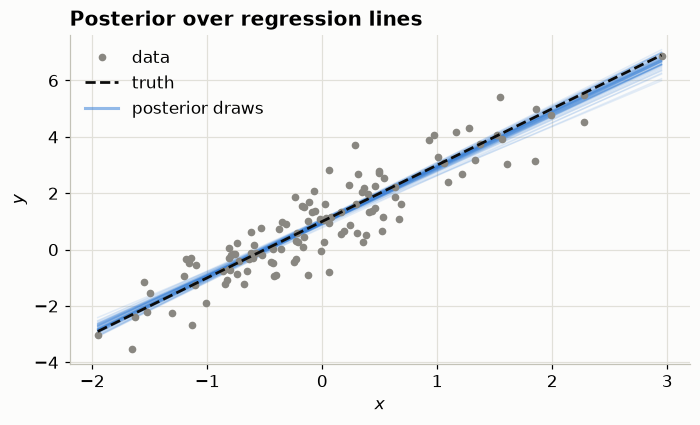

In [21]:
# Extract the posterior samples as an xarray dataset
post_p = idata_pymc.posterior.dataset

# Create a dense grid of x values spanning the observed data
xs = np.linspace(x.min(), x.max(), 100)

# Randomly sample 60 draws from the posterior (without replacement)
# This is for visualizing plausible regression lines
draws = rng.choice(post_p["Intercept"].values.size, 60, replace=False)

# Extract the sampled intercept and slope values (flatten to 1D)
ic = post_p["Intercept"].values.ravel()[draws]
sl = post_p["x"].values.ravel()[draws]

# Initialize the plot
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot 60 regression lines corresponding to random posterior draws
# These demonstrate plausible regression solutions the model considers likely
for i, s in zip(ic, sl):
    ax.plot(xs, i + s * xs, color=S.PRIMARY, alpha=0.12, lw=1)

# Plot the observed data points
ax.plot(
    x, y, 
    "o",                     # Marker style
    color=S.MUTED,           # Color for data
    ms=4,                    # Marker size
    ls="none",               # No connecting lines
    label="data", 
    zorder=3
)

# Plot the true underlying regression line used to generate the data
ax.plot(
    xs, TRUE_INTERCEPT + TRUE_SLOPE * xs,
    "--",                    # Dashed line for the true regression
    color=S.TRUTH,
    lw=1.8,
    label="truth", 
    zorder=4
)

# Add a dummy line for the legend to clarify which lines are posterior samples
ax.plot([], [], color=S.PRIMARY, alpha=0.5, label="posterior draws")

# Add axis labels and a title
ax.set(
    title="Posterior over regression lines", 
    xlabel="$x$", 
    ylabel="$y$"
)
ax.legend()                   # Add legend
fig.tight_layout()            # Format the layout tightly for clarity

### The same picture, via `sample_posterior_predictive`

The plot above was assembled by hand: pull draws, multiply them out, draw
lines. That is useful once, because it shows there is no magic. But PyMC will
generate predictions for you, and it accounts for the observation noise
`sigma` as well as uncertainty in the coefficients — which the lines do not.

Sampling: [y]


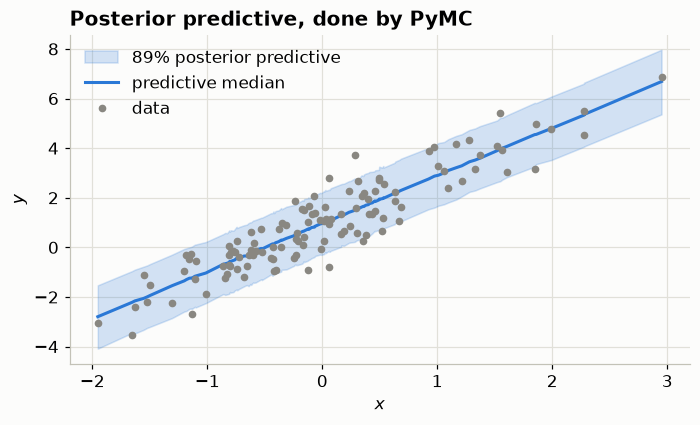

In [22]:
with regression:
    ppc_reg = pm.sample_posterior_predictive(idata_pymc, random_seed=RANDOM_SEED,
                                             progressbar=False)

y_pred = ppc_reg["posterior_predictive"].dataset["y"].values  # (chain, draw, obs)
y_pred = y_pred.reshape(-1, y_pred.shape[-1])
lo, mid, hi = np.percentile(y_pred, [5.5, 50, 94.5], axis=0)

order = np.argsort(x)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.fill_between(x[order], lo[order], hi[order], color=S.PRIMARY, alpha=0.20,
                label="89% posterior predictive")
ax.plot(x[order], mid[order], color=S.PRIMARY, lw=2, label="predictive median")
ax.plot(x, y, "o", color=S.MUTED, ms=4, ls="none", label="data", zorder=3)
ax.set(title="Posterior predictive, done by PyMC", xlabel="$x$", ylabel="$y$")
ax.legend()
fig.tight_layout()

::: {.callout-important}
## Two different bands, and people mix them up
The **regression lines** above show uncertainty in the *mean* — where the line
is. This band shows uncertainty in a *future observation*, which also includes
the scatter $\sigma$ around the line. The second is always wider, and it is
the one to use when the question is "what value would I see next?"
:::

One limitation is worth noticing now, because it sets up the next section.
`sample_posterior_predictive` predicts at the $x$ values the model was
**built with**. To predict at *new* $x$ — the usual reason you fit a
regression — you have to restructure the model so the covariate is a
`pm.Data` container and then swap it with `pm.set_data`. Doable, but it is
extra machinery, and you have to plan for it in advance.

## 5. The same regression, in bambi

For standard regression structures, writing the graph out by hand is
repetitive. **bambi** takes a formula and builds the PyMC model for you.

In [23]:
model_bmb = bmb.Model("y ~ 1 + x", data)
print(model_bmb)

       Formula: y ~ 1 + x
        Family: gaussian
          Link: mu = identity
  Observations: 120
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.9544, sigma: 4.7928)
            x ~ Normal(mu: 0.0, sigma: 5.2536)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 1.9171)


Notice what `print(model)` gives you: the formula, the family, the link, and
**every prior bambi chose on your behalf**. Those priors are not arbitrary —
they are scaled to your data — but they are choices, and you should look at
them.

In [24]:
idata_bmb = model_bmb.fit(draws=1000,
                          tune=1000,
                          chains=4,
                          cores=1,
                          progressbar=False,
                          random_seed=RANDOM_SEED
                          )
print(az.summary(idata_bmb, kind="stats").to_string())

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sigma, Intercept, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


           mean     sd eti89_lb eti89_ub
sigma      0.78  0.052      0.7     0.86
Intercept  0.96  0.071     0.85      1.1
x           1.9  0.078      1.8      2.1


### There is no magic — look at the generated model

The best way to believe bambi is to make it show you the PyMC model it built.

In [25]:
print(type(model_bmb.backend.model))
for rv in model_bmb.backend.model.basic_RVs:
    print("  ", rv.name)

<class 'pymc.model.core.Model'>
   sigma
   Intercept
   x
   y


That is the same graph you wrote by hand in section 4, with bambi's own
naming. Compare the two side by side:

In [26]:
comparison = pd.DataFrame({
    "hand-written PyMC": az.summary(idata_pymc, kind="stats")["mean"],
    "bambi": az.summary(idata_bmb, kind="stats")["mean"].reindex(
        ["Intercept", "x", "sigma"]),
})
print(comparison.to_string())
print("\n(Small differences are Monte Carlo noise plus bambi's data-scaled priors.)")

          hand-written PyMC bambi
Intercept              0.96  0.96
x                       1.9   1.9
sigma                  0.78  0.78

(Small differences are Monte Carlo noise plus bambi's data-scaled priors.)


### Where bambi actually earns its keep

The formula is the least interesting part. What bambi buys you is everything
*after* the fit — and in particular, prediction at covariate values the model
never saw, which took extra planning in raw PyMC.

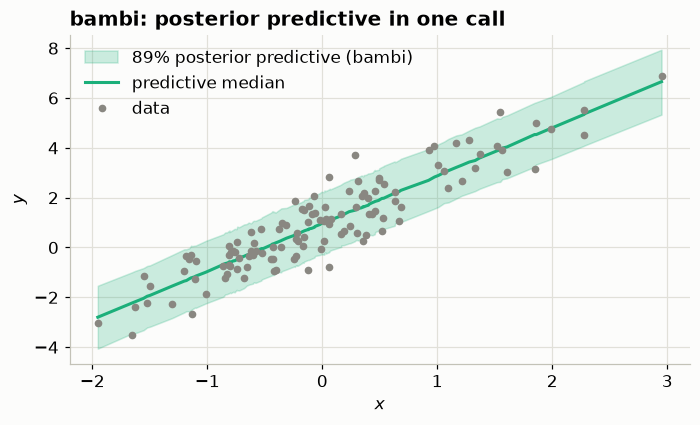

In [27]:
# Posterior predictive at the observed data: one argument.
model_bmb.predict(idata_bmb, kind="response", inplace=True)

pp = idata_bmb["posterior_predictive"].dataset["y"].values
pp = pp.reshape(-1, pp.shape[-1])
lo_b, mid_b, hi_b = np.percentile(pp, [5.5, 50, 94.5], axis=0)

order = np.argsort(data["x"].to_numpy())
xo = data["x"].to_numpy()[order]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.fill_between(xo, lo_b[order], hi_b[order], color=S.ALT, alpha=0.22,
                label="89% posterior predictive (bambi)")
ax.plot(xo, mid_b[order], color=S.ALT, lw=2, label="predictive median")
ax.plot(data["x"], data["y"], "o", color=S.MUTED, ms=4, ls="none",
        label="data", zorder=3)
ax.set(title="bambi: posterior predictive in one call", xlabel="$x$", ylabel="$y$")
ax.legend()
fig.tight_layout()

And now the part that mattered: **predicting out of sample.** Hand `predict` a
new dataframe and it does the rest — no `pm.Data`, no `set_data`, no rebuilding
the model.

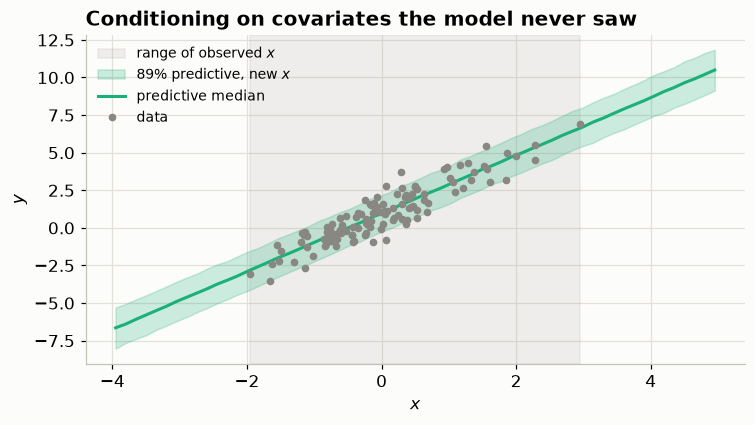

In [28]:
# Deliberately extrapolate beyond the observed range of x.
new_x = pd.DataFrame({"x": np.linspace(data["x"].min() - 2, data["x"].max() + 2, 60)})
oos = model_bmb.predict(idata_bmb, kind="response", data=new_x, inplace=False)

pp_new = oos["posterior_predictive"].dataset["y"].values
pp_new = pp_new.reshape(-1, pp_new.shape[-1])
lo_n, mid_n, hi_n = np.percentile(pp_new, [5.5, 50, 94.5], axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.axvspan(data["x"].min(), data["x"].max(), color=S.MUTED, alpha=0.12,
           label="range of observed $x$")
ax.fill_between(new_x["x"], lo_n, hi_n, color=S.ALT, alpha=0.22,
                label="89% predictive, new $x$")
ax.plot(new_x["x"], mid_n, color=S.ALT, lw=2, label="predictive median")
ax.plot(data["x"], data["y"], "o", color=S.MUTED, ms=4, ls="none", label="data")
ax.set(title="Conditioning on covariates the model never saw",
       xlabel="$x$", ylabel="$y$")
ax.legend(fontsize=9)
fig.tight_layout()

::: {.callout-tip}
## This is the argument for bambi in one picture
`model.predict(idata, data=new_x)` — that is the whole out-of-sample story.
For any model whose structure bambi can express, you get prediction,
marginalisation over covariates, and the `bmb.interpret` tools (predictions,
comparisons, slopes) without writing them.
:::

Note the band widens outside the shaded region. The model is extrapolating,
and it says so. It is still *only* honest about the uncertainty it knows
about — a straight line assumed to keep being straight. Widening error bars
are not a warrant for trusting an extrapolation.

### When to use which

| | write it in PyMC | write it in bambi |
|---|---|---|
| standard GLM / mixed model | works, verbose | one line |
| custom likelihood (e.g. a DDM) | the only option | no |
| non-standard structure | the only option | no |
| you want explicit control of every prior | yes | possible, but you are fighting it |

bambi is a front end, not a different engine. Everything you learn about PyMC
sampling, diagnostics and `DataTree` applies unchanged — which is why we did
it in this order.

### Exercise 3

Add a grouping variable to the simulated data (say 5 groups with different
intercepts), then write the bambi formula for a model with a **random
intercept per group**. Fit it and check that the group-level parameters
appear in the posterior.

<details>
<summary>Solution</summary>

```python
g = rng.integers(0, 5, n)
offsets = rng.normal(0, 1.5, 5)
data2 = data.assign(group=[f"g{i}" for i in g],
                    y=data["y"] + offsets[g])

m = bmb.Model("y ~ x + (1|group)", data2)
print(m)
idata2 = m.fit(draws=1000, tune=1000, chains=4, cores=1,
               progressbar=False, random_seed=RANDOM_SEED)
print(az.summary(idata2, kind="stats").to_string())
```

`(1|group)` is a random intercept. You should see `1|group` entries plus a
`1|group_sigma` — the population spread of the group intercepts. That
`_sigma` is the parameter whose geometry we spend all of Day 3, 11:00 on.

</details>

## 6. Optional: the `do` operator

*(Skip if we are short on time — nothing later depends on it.)*

PyMC can **intervene** on a model, not just condition on it. `pm.do` replaces
a variable with a fixed value and **cuts the arrows coming into it**. That is
a different operation from observing the same value, and the difference is the
whole of causal inference in one idea.

To see it you need a model where something upstream exists. Take a chain:

$$
z \sim \mathcal{N}(0, 1), \qquad
x \mid z \sim \mathcal{N}(z,\ 0.5), \qquad
y \mid x \sim \mathcal{N}(x,\ 0.5).
$$

Now ask what we learn about $z$ in two scenarios: we **observe** $x = 2$,
versus we **set** $x = 2$ ourselves.

In [29]:
with pm.Model() as chain:
    z = pm.Normal("z", 0.0, 1.0)
    x_var = pm.Normal("x_var", mu=z, sigma=0.5)
    pm.Normal("y_var", mu=x_var, sigma=0.5)

# (a) OBSERVE x = 2  -> evidence flows backwards, z updates
observed = pm.observe(chain, {chain["x_var"]: 2.0})
with observed:
    idata_obs = pm.sample(draws=1000, tune=1000, chains=2, cores=1,
                          nuts_sampler="pymc", progressbar=False,
                          random_seed=RANDOM_SEED)

# (b) DO x = 2  -> the z -> x arrow is cut, z keeps its prior
intervened = pm.do(chain, {chain["x_var"]: 2.0})
with intervened:
    idata_do = pm.sample_prior_predictive(draws=2000, random_seed=RANDOM_SEED)

z_obs = idata_obs.posterior.dataset["z"].values.ravel()
z_do = idata_do["prior"].dataset["z"].values.ravel()
print(f"E[z | observe x=2] = {z_obs.mean():+.3f}")
print(f"E[z | do(x=2)]     = {z_do.mean():+.3f}   (prior mean is 0)")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [z, y_var]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling: [y_var, z]


E[z | observe x=2] = +1.582
E[z | do(x=2)]     = +0.004   (prior mean is 0)


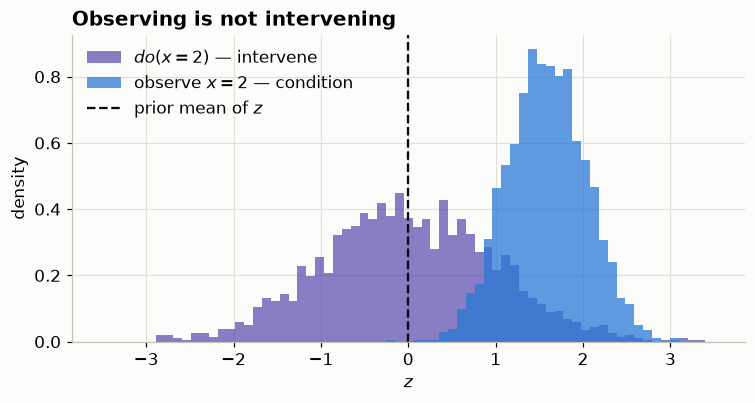

In [30]:
fig, ax = plt.subplots(figsize=(7, 3.8))
bins = np.linspace(-3.5, 3.5, 70)
ax.hist(z_do, bins=bins, density=True, color=S.NAIVE, alpha=0.65,
        label="$do(x=2)$ — intervene")
ax.hist(z_obs, bins=bins, density=True, color=S.PRIMARY, alpha=0.75,
        label="observe $x=2$ — condition")
S.truth_line(ax, 0.0, axis="x", label="prior mean of $z$")
ax.set(title="Observing is not intervening", xlabel="$z$", ylabel="density")
ax.legend()
fig.tight_layout()

**Observing** $x = 2$ is evidence: $x$ is downstream of $z$, so a high $x$
makes a high $z$ more plausible and the posterior shifts. **Intervening** —
reaching in and setting $x$ — destroys that inferential link, because the
value no longer came from $z$. $z$ keeps its prior.

::: {.callout-note}
## Why a modelling library has this at all
Once you can express interventions, a fitted model can answer "what would
happen if we *changed* this?" rather than only "what tends to go with what?".
`pm.do` and `pm.observe` return **new models**, leaving the original
untouched, so you can ask several such questions off one fit. HSSM exposes the
same idea as `model.sample_do(...)` — you will see it on Day 3.
:::

## What to take away

::: {.callout-tip}
## The five things that matter

1. **A distribution is used two ways.** `pm.Normal.dist(...)` is a value you
   can draw from and take `logp` of. `pm.Normal("name", ...)` inside a model
   context is a **node in a graph**, and the name is how you get results back.
2. **You are building a graph, not running code.** PyTensor differentiates and
   compiles it — the same machinery as a deep learning framework, aimed at a
   posterior instead of a loss.
3. **`pm.sample()` returns an `xarray.DataTree`.** `idata.posterior` is a tree
   *node*; reach through `.dataset` when you want Dataset behaviour.
4. **Look at the joint, not just the marginals**, and mark ground truth
   whenever you have it.
5. **Prior → posterior and prior predictive → posterior predictive** are the
   two pictures that show what conditioning did, in parameter space and in
   data space.
:::

### Quick reference

| want to | call |
|---|---|
| draw from a distribution | `pm.draw(pm.Normal.dist(0, 1), draws=n)` |
| evaluate a log-density | `pm.logp(dist, values).eval()` |
| see the model structure | `pm.model_to_graphviz(model)` |
| fit | `pm.sample(...)` |
| summarise | `az.summary(idata, kind="stats")` |
| first look | `az.plot_trace_dist(idata, combined=True)` |
| joint posterior | `az.plot_pair(idata, marginal=True, marginal_kind="kde")` |
| check before fitting | `pm.sample_prior_predictive(...)` |
| check after fitting | `pm.sample_posterior_predictive(...)` |
| intervene | `pm.do(model, {var: value})` |
| the same, as a formula | `bmb.Model("y ~ 1 + x", data).fit()` |
| predict at new covariates | `bmb_model.predict(idata, data=new_df)` |

::: {.callout-warning}
## Remember the version trap
`az.plot_posterior`, `az.plot_ppc`, `az.plot_density`, `az.plot_kde` and
`az.waic` no longer exist, and the default interval is an **89% ETI**. Almost
everything you find by searching predates that change.
:::

**Next:** we stop assuming the sampler works, and start looking at when it
does not.